In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest
from statsmodels.stats.proportion import proportion_confint
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("Libraries imported ✅")

Libraries imported ✅


In [2]:
df = pd.read_csv('C:/Users/Yashwanth u/Desktop/Data_projects/ab-testing/data/raw/ab_data_clean.csv')

control   = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']

control_conv   = control['converted'].sum()
treatment_conv = treatment['converted'].sum()
control_n      = len(control)
treatment_n    = len(treatment)
control_rate   = control['converted'].mean()
treatment_rate = treatment['converted'].mean()

conversions = np.array([control_conv, treatment_conv])
nobs        = np.array([control_n, treatment_n])
z_stat, p_value = proportions_ztest(conversions, nobs)

control_ci   = proportion_confint(control_conv, control_n, alpha=0.05)
treatment_ci = proportion_confint(treatment_conv, treatment_n, alpha=0.05)

print("Data loaded & metrics recalculated ✅")

Data loaded & metrics recalculated ✅


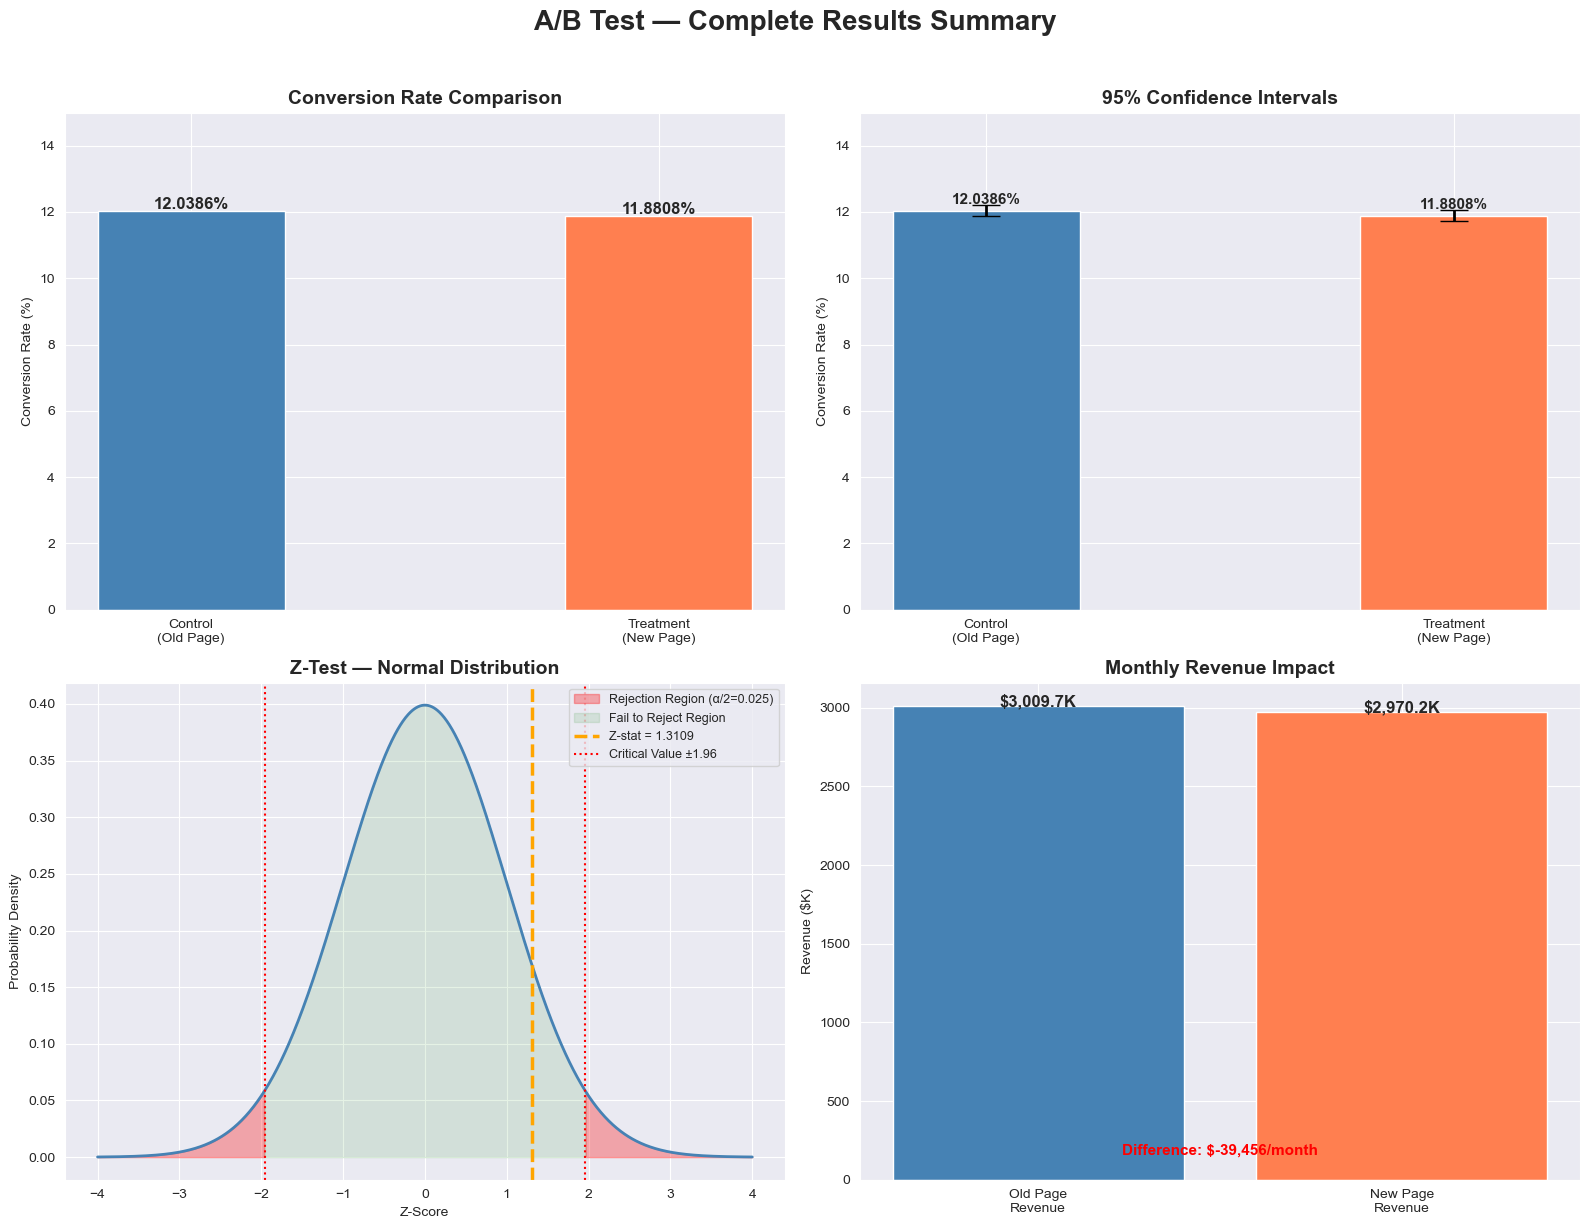

✅ Complete results chart saved!


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('A/B Test — Complete Results Summary',
             fontsize=20, fontweight='bold', y=1.02)

# Chart 1 — Conversion Rates
groups = ['Control\n(Old Page)', 'Treatment\n(New Page)']
rates  = [control_rate*100, treatment_rate*100]
colors = ['steelblue', 'coral']

bars = axes[0,0].bar(groups, rates, color=colors, width=0.4)
for bar, val in zip(bars, rates):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.05,
                   f'{val:.4f}%', ha='center',
                   fontweight='bold', fontsize=12)
axes[0,0].set_title('Conversion Rate Comparison',
                     fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Conversion Rate (%)')
axes[0,0].set_ylim(0, 15)

# Chart 2 — Confidence Intervals
errors = [
    (control_ci[1] - control_ci[0])*100/2,
    (treatment_ci[1] - treatment_ci[0])*100/2
]
bars2 = axes[0,1].bar(groups, rates, color=colors,
                       width=0.4, yerr=errors,
                       capsize=10,
                       error_kw={'linewidth': 2})
for bar, val in zip(bars2, rates):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.2,
                   f'{val:.4f}%', ha='center',
                   fontweight='bold', fontsize=11)
axes[0,1].set_title('95% Confidence Intervals',
                     fontsize=14, fontweight='bold')
axes[0,1].set_ylabel('Conversion Rate (%)')
axes[0,1].set_ylim(0, 15)

# Chart 3 — P-Value Visualization
ax3 = axes[1,0]
x = np.linspace(-4, 4, 1000)
y = stats.norm.pdf(x, 0, 1)

ax3.plot(x, y, color='steelblue', linewidth=2)
ax3.fill_between(x, y, where=(x <= -1.96),
                 color='red', alpha=0.3,
                 label='Rejection Region (α/2=0.025)')
ax3.fill_between(x, y, where=(x >= 1.96),
                 color='red', alpha=0.3)
ax3.fill_between(x, y,
                 where=((x >= -1.96) & (x <= 1.96)),
                 color='green', alpha=0.1,
                 label='Fail to Reject Region')
ax3.axvline(x=z_stat, color='orange', linewidth=2.5,
            linestyle='--',
            label=f'Z-stat = {z_stat:.4f}')
ax3.axvline(x=1.96, color='red', linewidth=1.5,
            linestyle=':', label='Critical Value ±1.96')
ax3.axvline(x=-1.96, color='red', linewidth=1.5,
            linestyle=':')
ax3.set_title('Z-Test — Normal Distribution',
              fontsize=14, fontweight='bold')
ax3.set_xlabel('Z-Score')
ax3.set_ylabel('Probability Density')
ax3.legend(fontsize=9)

# Chart 4 — Business Impact
ax4 = axes[1,1]
monthly_visitors = 500000
avg_order_value  = 50

old_revenue = monthly_visitors * control_rate * avg_order_value
new_revenue = monthly_visitors * treatment_rate * avg_order_value
diff        = new_revenue - old_revenue

revenue_data = [old_revenue/1000, new_revenue/1000]
bars4 = ax4.bar(['Old Page\nRevenue',
                  'New Page\nRevenue'],
                 revenue_data,
                 color=['steelblue','coral'])

for bar, val in zip(bars4, revenue_data):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             f'${val:,.1f}K', ha='center',
             fontweight='bold', fontsize=12)

ax4.set_title('Monthly Revenue Impact',
              fontsize=14, fontweight='bold')
ax4.set_ylabel('Revenue ($K)')
ax4.annotate(f'Difference: ${diff:,.0f}/month',
             xy=(0.5, 0.05),
             xycoords='axes fraction',
             ha='center', fontsize=11,
             color='red' if diff < 0 else 'green',
             fontweight='bold')

plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/ab-testing/data/raw/07_complete_results.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Complete results chart saved!")

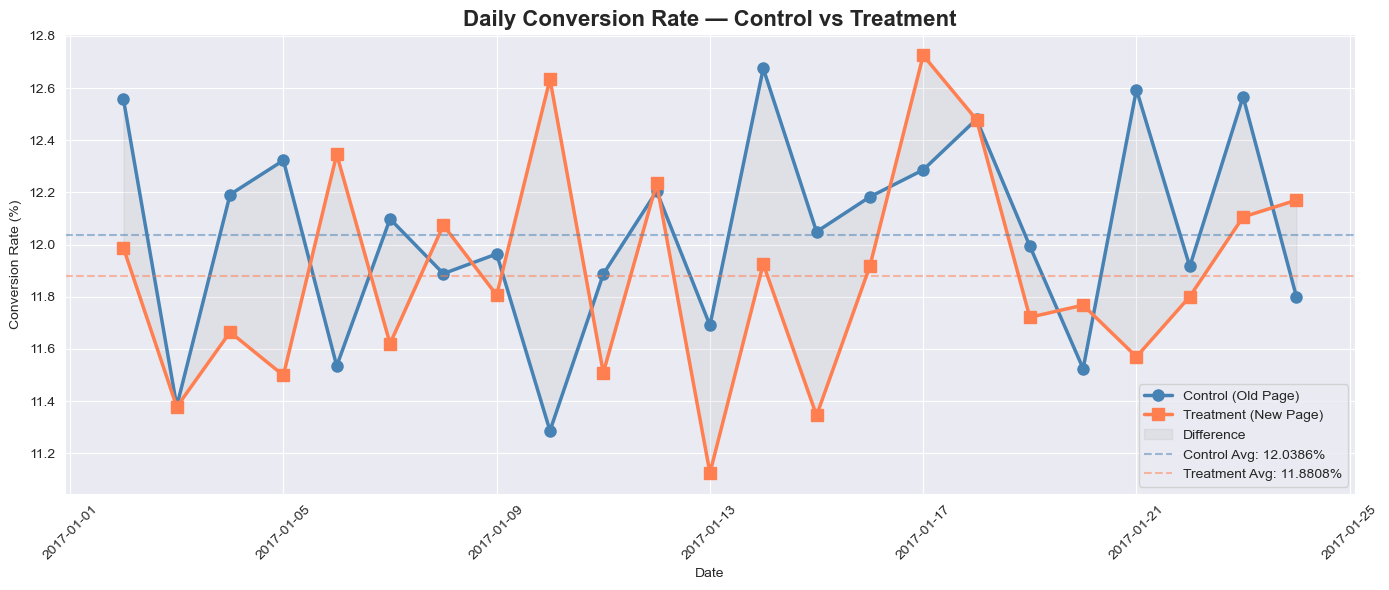

In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
daily = df.groupby([df['timestamp'].dt.date, 'group'])['converted'].mean().reset_index()
daily.columns = ['date', 'group', 'conv_rate']
daily['conv_rate'] = daily['conv_rate'] * 100
daily['date'] = pd.to_datetime(daily['date'])

control_daily   = daily[daily['group'] == 'control']
treatment_daily = daily[daily['group'] == 'treatment']

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(control_daily['date'], control_daily['conv_rate'],
        marker='o', color='steelblue', linewidth=2.5,
        markersize=8, label='Control (Old Page)')
ax.plot(treatment_daily['date'], treatment_daily['conv_rate'],
        marker='s', color='coral', linewidth=2.5,
        markersize=8, label='Treatment (New Page)')
ax.fill_between(control_daily['date'],
                control_daily['conv_rate'],
                treatment_daily['conv_rate'],
                alpha=0.1, color='gray',
                label='Difference')
ax.axhline(y=control_rate*100, color='steelblue',
           linestyle='--', alpha=0.5,
           label=f'Control Avg: {control_rate*100:.4f}%')
ax.axhline(y=treatment_rate*100, color='coral',
           linestyle='--', alpha=0.5,
           label=f'Treatment Avg: {treatment_rate*100:.4f}%')
ax.set_title('Daily Conversion Rate — Control vs Treatment',
             fontsize=16, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Conversion Rate (%)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('C:/Users/Yashwanth u/Desktop/Data_projects/ab-testing/data/raw/08_daily_comparison.png', dpi=150)
plt.show()

In [6]:
print("=" * 65)
print("📋 FINAL A/B TEST BUSINESS REPORT")
print("=" * 65)
print(f"""
EXPERIMENT OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Test Type      : Two-proportion Z-test
Test Duration  : 23 days (Jan 2 – Jan 24, 2017)
Total Users    : {len(df):,}
Control Group  : {control_n:,} users (Old Landing Page)
Treatment Group: {treatment_n:,} users (New Landing Page)

RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Control Conv Rate   : {control_rate*100:.4f}%
Treatment Conv Rate : {treatment_rate*100:.4f}%
Absolute Difference : {(treatment_rate-control_rate)*100:.4f}%
Relative Change     : {((treatment_rate-control_rate)/control_rate)*100:.2f}%

STATISTICAL ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Z-Statistic         : {z_stat:.4f}
P-Value             : {p_value:.4f}
Significance Level  : 0.05
Result              : FAIL TO REJECT NULL HYPOTHESIS

CONFIDENCE INTERVALS (95%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Control   : ({control_ci[0]*100:.4f}%, {control_ci[1]*100:.4f}%)
Treatment : ({treatment_ci[0]*100:.4f}%, {treatment_ci[1]*100:.4f}%)

BUSINESS IMPACT (500K monthly visitors, $50 AOV)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Old Page Revenue    : ${500000*control_rate*50:,.2f}/month
New Page Revenue    : ${500000*treatment_rate*50:,.2f}/month
Revenue Difference  : ${500000*(treatment_rate-control_rate)*50:,.2f}/month
Annual Impact       : ${500000*(treatment_rate-control_rate)*50*12:,.2f}/year

VERDICT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DO NOT launch the new landing page.

The new page shows NO statistically significant
improvement over the old page (p=0.19 > 0.05).
Launching it would risk losing ${abs(500000*(treatment_rate-control_rate)*50*12):,.2f}
in annual revenue.

RECOMMENDATIONS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. Keep old landing page — better conversion rate
2. Investigate WHY new page underperforms
   (UX research, heatmaps, user interviews)
3. Run new A/B test with specific element changes
   (CTA button, headline, hero image) not full redesign
4. Test for longer duration (30+ days) for seasonal effects
""")
print("=" * 65)

📋 FINAL A/B TEST BUSINESS REPORT

EXPERIMENT OVERVIEW
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Test Type      : Two-proportion Z-test
Test Duration  : 23 days (Jan 2 – Jan 24, 2017)
Total Users    : 290,584
Control Group  : 145,274 users (Old Landing Page)
Treatment Group: 145,310 users (New Landing Page)

RESULTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Control Conv Rate   : 12.0386%
Treatment Conv Rate : 11.8808%
Absolute Difference : -0.1578%
Relative Change     : -1.31%

STATISTICAL ANALYSIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Z-Statistic         : 1.3109
P-Value             : 0.1899
Significance Level  : 0.05
Result              : FAIL TO REJECT NULL HYPOTHESIS

CONFIDENCE INTERVALS (95%)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Control   : (11.8713%, 12.2060%)
Treatment : (11.7144%, 12.0472%)

BUSINESS IMPACT (500K monthly visitors, $50 AOV)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Old Page Revenue    : $3

In [7]:
results = {
    'Metric': [
        'Total Users',
        'Control Users',
        'Treatment Users',
        'Control Conv Rate',
        'Treatment Conv Rate',
        'Difference',
        'Z-Statistic',
        'P-Value',
        'Significant',
        'Verdict'
    ],
    'Value': [
        f"{len(df):,}",
        f"{control_n:,}",
        f"{treatment_n:,}",
        f"{control_rate*100:.4f}%",
        f"{treatment_rate*100:.4f}%",
        f"{(treatment_rate-control_rate)*100:.4f}%",
        f"{z_stat:.4f}",
        f"{p_value:.4f}",
        "No (p > 0.05)",
        "Keep Old Page"
    ]
}

results_df = pd.DataFrame(results)
results_df.to_csv('C:/Users/Yashwanth u/Desktop/Data_projects/ab-testing/data/raw/ab_test_results.csv', index=False)
print("✅ Results saved!")
print(results_df.to_string(index=False))

✅ Results saved!
             Metric         Value
        Total Users       290,584
      Control Users       145,274
    Treatment Users       145,310
  Control Conv Rate      12.0386%
Treatment Conv Rate      11.8808%
         Difference      -0.1578%
        Z-Statistic        1.3109
            P-Value        0.1899
        Significant No (p > 0.05)
            Verdict Keep Old Page
